## Figure 4 — Zero-shot evaluation

Layout: curves with 95% CI shading + scalar dot-whisker panels.

| Cell | Content | Output |
|---|---|---|
| 1 | Imports & setup | — |
| 2 | Palette & file registry | — |
| 3 | Bootstrap (run once) | `results` dict |
| 4 | ROC curves with CI — ZS1 & ZS2 | `fig4_roc_zs1/2.pdf` |
| 5 | PR curves with CI — ZS1 & ZS2 | `fig4_pr_zs1/2.pdf` |
| 6 | Dot-whisker — AUROC (ZS1) + AP (ZS2) | `fig4_dw_auroc.pdf`, `fig4_dw_ap.pdf` |
| 7 | CI summary table | stdout |


In [77]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve)

_here = os.path.abspath('.')
if os.path.basename(_here) in ('notebook', 'analysis'):
    os.chdir(os.path.dirname(_here))

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42
matplotlib.rcParams['font.size']    = 9

FIG_DIR = 'analysis/figures'
PRED    = 'pred_results'
os.makedirs(FIG_DIR, exist_ok=True)


In [78]:
# ── Palette, display names, file paths ────────────────────────────────────────

ZS_MODELS = ['ImmunoMTL', 'BigMHC', 'MUNIS', 'PRIME2', 'netMHCpan', 'MHCflurry']

COLORS = {
    'ImmunoMTL': '#4E526E',
    'STL':       '#E07A5F',
    'ABC':       '#B8A8C8',
    'JointSTL':  '#8BAAB8',
    'Shuffle':   '#D3D3D3',
    'BigMHC':    '#F6D5A0',
    'MUNIS':     '#92BEAA',
    'PRIME2':    '#718B8E',
    'netMHCpan': '#606060',
    'MHCflurry': '#F0C3AF',
}

DISPLAY = {
    'ImmunoMTL': 'ImmunoMTL',
    'BigMHC':    'BigMHC',
    'MUNIS':     'MUNIS',
    'PRIME2':    'PRIME 2.0',
    'netMHCpan': 'netMHCpan 4.1',
    'MHCflurry': 'MHCflurry 2.0',
}

def darken(hex_c, f=0.62):
    r = int(int(hex_c[1:3], 16) * f)
    g = int(int(hex_c[3:5], 16) * f)
    b = int(int(hex_c[5:7], 16) * f)
    return f'#{r:02x}{g:02x}{b:02x}'

DARK = {m: darken(c) for m, c in COLORS.items()}

MTL_ZS1 = f'{PRED}/MTL/zero1_predictions.csv'
MTL_ZS2 = f'{PRED}/MTL/zero2_predictions.csv'

ZS_FILES = {
    'zero1': {
        'ImmunoMTL': (MTL_ZS1,                                          'score',                             False, None),
        'BigMHC':    (f'{PRED}/bigmhc/zero1_bigmhc.csv',                'BigMHC_IM',                         False, MTL_ZS1),
        'MUNIS':     (f'{PRED}/munis/zero1_munis_predictions.csv',       'score',                             False, None),
        'PRIME2':    (f'{PRED}/prime2/zero1_prime.csv',                  'PRIME_rank',                        True,  None),
        'netMHCpan': (f'{PRED}/netMHCpan/zero1_netMHCpan.csv',          'EL_Rank',                           True,  None),
        'MHCflurry': (f'{PRED}/mhcflurry/zero1_mhcflurry.csv',          'mhcflurry_presentation_percentile', True,  None),
    },
    'zero2': {
        'ImmunoMTL': (MTL_ZS2,                                          'score',                             False, None),
        'BigMHC':    (f'{PRED}/bigmhc/zero2_bigmhc.csv',                'BigMHC_IM',                         False, MTL_ZS2),
        'MUNIS':     (f'{PRED}/munis/zero2_munis_predictions.csv',       'score',                             False, None),
        'PRIME2':    (f'{PRED}/prime2/zero2_prime.csv',                  'PRIME_rank',                        True,  None),
        'netMHCpan': (f'{PRED}/netMHCpan/zero2_netMHCpan.csv',          'EL_Rank',                           True,  None),
        'MHCflurry': (f'{PRED}/mhcflurry/zero2_mhcflurry.csv',          'mhcflurry_presentation_percentile', True,  None),
    },
}


In [79]:
# ── Bootstrap (run once — ~1–2 min) ───────────────────────────────────────────

N_BOOT   = 1000
N_PTS    = 300
RNG      = np.random.default_rng(42)
FPR_GRID = np.linspace(0, 1, N_PTS)
REC_GRID = np.linspace(0, 1, N_PTS)

def load_pred(path, score_col, negate=False, label_source=None):
    df = pd.read_csv(path)
    if 'pep' in df.columns and 'Peptide' not in df.columns:
        df = df.rename(columns={'pep': 'Peptide'})
    if 'mhc' in df.columns and 'MHC' not in df.columns:
        df = df.rename(columns={'mhc': 'MHC'})
    if label_source is not None:
        ref = pd.read_csv(label_source)[['Peptide', 'MHC', 'Label']]
        df  = df.merge(ref, on=['Peptide', 'MHC'], how='left')
    yp = df[score_col].values.astype(float)
    if negate:
        yp = -yp
    yt = df['Label'].values.astype(float)
    mask = ~(np.isnan(yt) | np.isnan(yp))
    return yt[mask], yp[mask]

def run_bootstrap(yt, yp):
    aurocs, aps, roc_tprs, pr_precs = [], [], [], []
    for _ in range(N_BOOT):
        idx = RNG.choice(len(yt), len(yt), replace=True)
        yb, pb = yt[idx], yp[idx]
        if yb.sum() == 0 or yb.sum() == len(yb):
            continue
        aurocs.append(roc_auc_score(yb, pb))
        aps.append(average_precision_score(yb, pb))
        fpr, tpr, _ = roc_curve(yb, pb)
        roc_tprs.append(np.interp(FPR_GRID, fpr, tpr))
        prec, rec, _ = precision_recall_curve(yb, pb)
        pr_precs.append(np.interp(REC_GRID, rec[::-1], prec[::-1]))
    a, p = np.array(aurocs), np.array(aps)
    rt, pp = np.array(roc_tprs), np.array(pr_precs)
    return dict(
        auroc=a, ap=p,
        roc_mean=rt.mean(0),  roc_lo=np.percentile(rt, 2.5, 0),  roc_hi=np.percentile(rt, 97.5, 0),
        pr_mean=pp.mean(0),   pr_lo=np.percentile(pp, 2.5, 0),   pr_hi=np.percentile(pp, 97.5, 0),
    )

results = {}
for ds, model_files in ZS_FILES.items():
    results[ds] = {}
    for model, (path, col, neg, lsrc) in model_files.items():
        if not os.path.exists(path):
            print(f'[SKIP] {ds}/{model}')
            continue
        yt, yp = load_pred(path, col, neg, lsrc)
        b = run_bootstrap(yt, yp)
        pt_auroc = roc_auc_score(yt, yp)
        pt_ap    = average_precision_score(yt, yp)
        results[ds][model] = dict(
            yt=yt, yp=yp, pos_rate=yt.mean(),
            auroc=pt_auroc, auroc_lo=np.percentile(b['auroc'], 2.5), auroc_hi=np.percentile(b['auroc'], 97.5),
            ap=pt_ap,       ap_lo=np.percentile(b['ap'],    2.5),    ap_hi=np.percentile(b['ap'],    97.5),
            **{k: b[k] for k in ('roc_mean','roc_lo','roc_hi','pr_mean','pr_lo','pr_hi')},
        )
        print(f'  {ds}  {model:<12}  '
              f'AUROC {pt_auroc:.3f} [{np.percentile(b["auroc"],2.5):.3f}\u2013{np.percentile(b["auroc"],97.5):.3f}]  '
              f'AP {pt_ap:.3f} [{np.percentile(b["ap"],2.5):.3f}\u2013{np.percentile(b["ap"],97.5):.3f}]')
print('Done.')


  zero1  ImmunoMTL     AUROC 0.638 [0.595–0.680]  AP 0.272 [0.220–0.338]
  zero1  BigMHC        AUROC 0.590 [0.539–0.643]  AP 0.352 [0.282–0.430]
  zero1  MUNIS         AUROC 0.436 [0.378–0.491]  AP 0.203 [0.155–0.257]
  zero1  PRIME2        AUROC 0.340 [0.292–0.393]  AP 0.130 [0.108–0.161]
  zero1  netMHCpan     AUROC 0.356 [0.298–0.411]  AP 0.154 [0.122–0.196]
  zero1  MHCflurry     AUROC 0.381 [0.328–0.433]  AP 0.156 [0.124–0.203]
  zero2  ImmunoMTL     AUROC 0.596 [0.417–0.791]  AP 0.873 [0.779–0.958]
  zero2  BigMHC        AUROC 0.344 [0.179–0.515]  AP 0.790 [0.671–0.905]
  zero2  MUNIS         AUROC 0.325 [0.172–0.491]  AP 0.779 [0.670–0.892]
  zero2  PRIME2        AUROC 0.592 [0.437–0.736]  AP 0.884 [0.794–0.960]
  zero2  netMHCpan     AUROC 0.262 [0.133–0.386]  AP 0.748 [0.626–0.876]
  zero2  MHCflurry     AUROC 0.317 [0.175–0.476]  AP 0.799 [0.683–0.905]
Done.


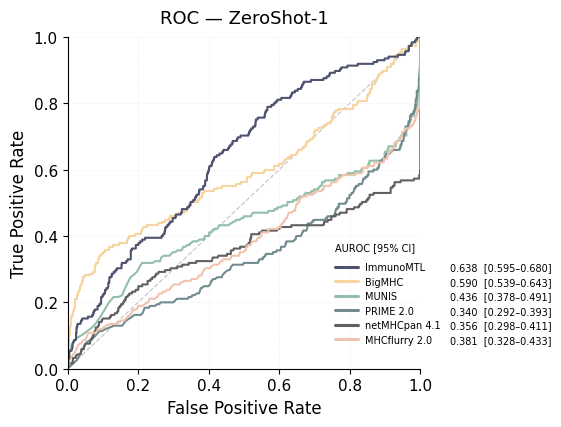

Saved fig4_roc_zero1.{pdf,png}


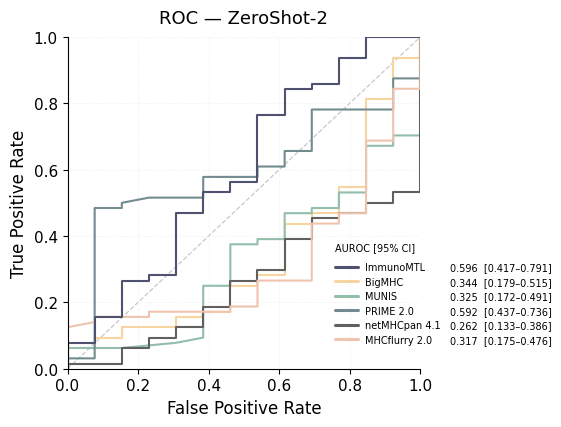

Saved fig4_roc_zero2.{pdf,png}


In [86]:
# ── ROC curves + AUROC inset table ────────────────────────────────────────────

CURVE_ORDER = ['BigMHC', 'MUNIS', 'PRIME2', 'netMHCpan', 'MHCflurry', 'ImmunoMTL']

def draw_table_inset(ax, ds, metric_k, lo_k, hi_k, header,
                     loc=(0.40, 0.04, 0.58, 0.50)):
    axin = ax.inset_axes(loc)
    axin.set_xlim(0, 1); axin.set_ylim(0, 1)
    axin.set_axis_off()
    axin.patch.set_visible(False)

    PAD = 0.09

    axin.text(PAD, 1 - PAD * 0.5, header, fontsize=7, fontweight='normal',
              color='#000000', va='top', transform=axin.transAxes)

    rows = [m for m in ZS_MODELS if m in results.get(ds, {})]
    step = (1 - PAD * 3.8) / len(rows)
    y0   = 1 - PAD * 2.2

    for i, model in enumerate(rows):
        r    = results[ds][model]
        y    = y0 - i * step
        ymid = y - step * 0.30

        axin.plot([PAD, PAD + 0.10], [ymid, ymid],
                  color=COLORS[model], lw=2.2,
                  solid_capstyle='round', clip_on=False)

        axin.text(PAD + 0.13, y, DISPLAY[model], fontsize=7, color='#000000',
                  fontweight='normal', va='top', transform=axin.transAxes)

        val = f"{r[metric_k]:.3f}  [{r[lo_k]:.3f}\u2013{r[hi_k]:.3f}]"
        axin.text(PAD + 0.50, y, val, fontsize=7, color='#000000',
                  va='top', transform=axin.transAxes)

for ds, ds_label in [('zero1', 'ZeroShot-1'), ('zero2', 'ZeroShot-2')]:
    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    fig.subplots_adjust(left=0.13, right=0.97, top=0.92, bottom=0.13)

    for model in CURVE_ORDER:
        r = results.get(ds, {}).get(model)
        if r is None:
            continue
        fpr, tpr, _ = roc_curve(r['yt'], r['yp'])
        ax.plot(fpr, tpr, color=COLORS[model], lw=1.5, zorder=2)

    ax.plot([0,1],[0,1], ls='--', color='#C8C8C8', lw=0.9, zorder=0)

    draw_table_inset(ax, ds, 'auroc', 'auroc_lo', 'auroc_hi',
                     'AUROC [95% CI]', loc=(0.70, 0.0, 0.65, 0.4))

    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('False Positive Rate', fontsize=12, labelpad=4)
    ax.set_ylabel('True Positive Rate',  fontsize=12, labelpad=4)
    ax.set_title(f'ROC \u2014 {ds_label}', fontsize=13, pad=10)
    ax.tick_params(labelsize=11, width=0.8)
    ax.spines[['top','right']].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.xaxis.grid(True, ls=':', lw=0.5, color='#E8E8E8', zorder=0)
    ax.yaxis.grid(True, ls=':', lw=0.5, color='#E8E8E8', zorder=0)
    ax.set_axisbelow(True)

    fname = f'fig4_roc_{ds}'
    plt.savefig(os.path.join(FIG_DIR, f'{fname}.pdf'), bbox_inches='tight')
    plt.savefig(os.path.join(FIG_DIR, f'{fname}.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}.{{pdf,png}}')


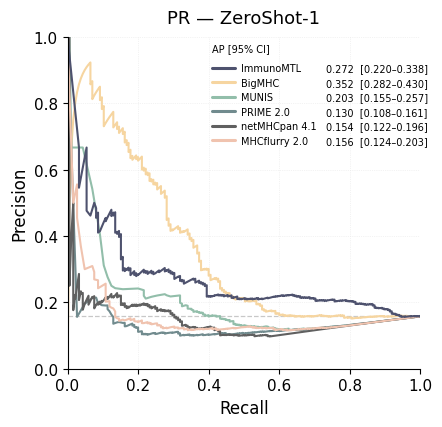

Saved fig4_pr_zero1.{pdf,png}


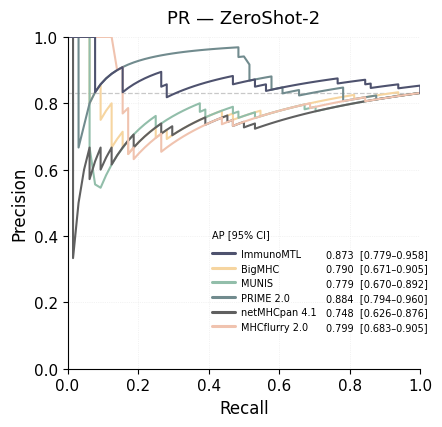

Saved fig4_pr_zero2.{pdf,png}


In [87]:
# ── PR curves + AP inset table ────────────────────────────────────────────────

for ds, ds_label in [('zero1', 'ZeroShot-1'), ('zero2', 'ZeroShot-2')]:
    pos_rate = next(r['pos_rate'] for r in results.get(ds,{}).values())

    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    fig.subplots_adjust(left=0.13, right=0.97, top=0.92, bottom=0.13)

    for model in CURVE_ORDER:
        r = results.get(ds, {}).get(model)
        if r is None:
            continue
        prec, rec, _ = precision_recall_curve(r['yt'], r['yp'])
        ax.plot(rec, prec, color=COLORS[model], lw=1.5, zorder=2)

    ax.axhline(pos_rate, ls='--', color='#C8C8C8', lw=0.9, zorder=0)

    inset_loc = (0.35, 0.6, 0.65, 0.40) if ds == 'zero1' else (0.35, 0.04, 0.65, 0.4)
    draw_table_inset(ax, ds, 'ap', 'ap_lo', 'ap_hi',
                     'AP [95% CI]', loc=inset_loc)

    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Recall',    fontsize=12, labelpad=4)
    ax.set_ylabel('Precision', fontsize=12, labelpad=4)
    ax.set_title(f'PR \u2014 {ds_label}', fontsize=13, pad=10)
    ax.tick_params(labelsize=11, width=0.8)
    ax.spines[['top','right']].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.xaxis.grid(True, ls=':', lw=0.5, color='#E8E8E8', zorder=0)
    ax.yaxis.grid(True, ls=':', lw=0.5, color='#E8E8E8', zorder=0)
    ax.set_axisbelow(True)

    fname = f'fig4_pr_{ds}'
    plt.savefig(os.path.join(FIG_DIR, f'{fname}.pdf'), bbox_inches='tight')
    plt.savefig(os.path.join(FIG_DIR, f'{fname}.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}.{{pdf,png}}')


In [82]:
# ── CI summary table ───────────────────────────────────────────────────────────
for ds in ('zero1', 'zero2'):
    print(f'\n{ds}')
    print(f"  {'Model':<16}  {'AUROC':>6}  95% CI              {'AP':>6}  95% CI")
    print('  ' + '-' * 62)
    for m in ZS_MODELS:
        if m not in results.get(ds, {}): continue
        r = results[ds][m]
        print(f"  {DISPLAY[m]:<16}  {r['auroc']:.3f}   ({r['auroc_lo']:.3f}–{r['auroc_hi']:.3f})"
              f"    {r['ap']:.3f}   ({r['ap_lo']:.3f}–{r['ap_hi']:.3f})")



zero1
  Model              AUROC  95% CI                  AP  95% CI
  --------------------------------------------------------------
  ImmunoMTL         0.638   (0.595–0.680)    0.272   (0.220–0.338)
  BigMHC            0.590   (0.539–0.643)    0.352   (0.282–0.430)
  MUNIS             0.436   (0.378–0.491)    0.203   (0.155–0.257)
  PRIME 2.0         0.340   (0.292–0.393)    0.130   (0.108–0.161)
  netMHCpan 4.1     0.356   (0.298–0.411)    0.154   (0.122–0.196)
  MHCflurry 2.0     0.381   (0.328–0.433)    0.156   (0.124–0.203)

zero2
  Model              AUROC  95% CI                  AP  95% CI
  --------------------------------------------------------------
  ImmunoMTL         0.596   (0.417–0.791)    0.873   (0.779–0.958)
  BigMHC            0.344   (0.179–0.515)    0.790   (0.671–0.905)
  MUNIS             0.325   (0.172–0.491)    0.779   (0.670–0.892)
  PRIME 2.0         0.592   (0.437–0.736)    0.884   (0.794–0.960)
  netMHCpan 4.1     0.262   (0.133–0.386)    0.748   (0.626–